In [ ]:
library(ape)

WORKDIR="/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.5.CARTA/"
sc <- read.delim("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byTypeReClustering/step7.metadata_nod.txt",header=T)
row.names(sc) <- gsub("-1$","",sc$cellID)
sc <- sc[,c(1,2,6)]

for(my.mouse in c("4007","4011","4033")){
    indir=paste0(WORKDIR,"trees/",my.mouse)
    setwd(indir)
    trees <- list.files(pattern="*nwk")
    for(my.tree in trees){
        clone=strsplit(my.tree,"_")[[1]][1]
        clone=gsub("Clone","",clone)
        tree <- read.tree(my.tree)
        tree <- drop.tip(tree,tree$tip.label[!(tree$tip.label %in% row.names(sc))])
        meta <- sc[tree$tip.label,]
        colnames(meta) <- c("cellBC","cell_state","StF_Group")
        meta$cellBC <- row.names(meta)
        row.names(meta) <- 0:(nrow(meta)-1)
        meta$cell_state <- ifelse(meta$cell_state %in% c(0,3,7,8),"E", ifelse(meta$cell_state %in% c(1,2,5),"N","H"))
        write.tree(tree, file = paste0(WORKDIR,"trees/",my.mouse,"_",clone,".nwk"))
        meta$StF_Group=""
        write.table(meta,file = paste0(WORKDIR,"states/",my.mouse,"_",clone,"_meta.txt"), row.names=T,quote=F,sep="\t")
        df <- data.frame(nwk=paste0(WORKDIR,"trees/",my.mouse,"_",clone,".nwk"),state=paste0(WORKDIR,"states/",my.mouse,"_",clone,"_meta.txt"))
        write.table(df,file = paste0(WORKDIR,"locations/",my.mouse,"_",clone,".txt"), row.names=F,quote=F,col.names=F,sep="\t")
    }
}


# 1. select k 值

In [202]:
setwd("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.5.CARTA/output")
clones=c("4007_1","4007_2","4007_3","4007_4","4007_5","4007_7","4007_8","4007_9","4007_10","4007_11","4007_12","4007_13","4007_14","4007_15",
         "4007_16","4007_17","4007_18","4007_19","4007_20","4007_21","4007_23","4007_24","4007_25","4007_26","4007_27","4007_28","4007_29","4007_31",
         "4007_32","4007_33","4007_34","4007_35","4007_36","4007_37","4007_38","4007_39","4007_40","4007_41","4007_42","4007_43","4007_44","4007_45",
         "4007_46","4007_47","4007_48","4007_49","4007_50","4007_53","4007_54","4007_55","4007_56","4007_62","4007_63","4007_68","4007_69","4007_73",
         "4011_2","4011_3","4011_4","4011_5","4011_6","4011_7","4011_8","4011_9","4011_10","4011_11","4011_12","4011_13","4011_14","4011_15","4011_16",
         "4011_17","4011_18","4011_20","4011_22","4011_25","4011_27","4011_28","4011_29","4011_30","4011_32","4011_33","4011_34","4011_35","4011_36",
         "4011_37","4011_38","4011_39","4011_40","4011_41","4011_42","4011_43","4011_44","4011_45","4011_46","4011_47","4011_48","4011_50","4011_51",
         "4011_52","4011_54","4011_55","4011_58","4011_64","4011_65","4011_67","4011_68","4011_71","4011_85",
         "4033_1","4033_2","4033_3","4033_5","4033_6","4033_7","4033_10","4033_11","4033_12","4033_13","4033_14","4033_15","4033_16","4033_17","4033_18",
         "4033_19","4033_20","4033_21","4033_22","4033_23","4033_25","4033_28","4033_29","4033_30","4033_31","4033_33","4033_34","4033_35","4033_36",
         "4033_37","4033_38","4033_40","4033_41","4033_45","4033_61")

In [223]:
pdf("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.5.CARTA/D-Progenitor.pdf",width = 5,height = 4.5,onefile = TRUE)
for(my.clone in clones){
    dt <- data.table()
    for(i in 1:7){
        pro <- read.delim(paste0(my.clone,"_progenitors_",i,".txt"),header=F)
        res <- read.delim(paste0(my.clone,"_results_",i,".txt"),header=T)
        dt <- rbind(dt,data.table(clone =my.clone, progenitor=nrow(pro),D=res$objective_score))
    }
   p <- ggplot(dt, aes(x = progenitor, y = D)) + geom_point(size = 3,color="orange") + geom_line(group = 1) + 
    theme_classic(base_size = 14) + labs(x = "Progenitor",y = "D") +ggtitle(my.clone)
    print(p)
}
dev.off()

pdf 
  2

# 2. 统计结果

In [ ]:
library(ape)
library(dplyr)
library(stringr)
library(data.table)
library(RColorBrewer)
library(tidyr)
library(pheatmap)


In [ ]:
setwd("/syn2/zhaolian/3.JiLab/results/3.PacBio/7.fitchHartigan")
treefiles <- list.files(pattern="*_fitchHartigan_organ_state.newick")

parse_state_set <- function(x) {
  if (!grepl("\\{", x)) return(x)
  x <- gsub("[\\{\\}' ]", "", x)
  unlist(strsplit(x, ","))
}

dt_alltranstions <- data.table()
for(my.tree in treefiles){
    my.clone <- gsub("_fitchHartigan_organ_state.newick","",my.tree)
    # 1. lod Newick tree 
    tree <- read.tree(my.tree)
    # 2. get all node labels
    node_labels <- tree$tip.label
    if(!is.null(tree$node.label)){
      node_labels <- c(node_labels, tree$node.label)
    }
    df <- data.frame(
      node = 1:(length(tree$tip.label) + tree$Nnode),
      label = node_labels,
      stringsAsFactors = FALSE
    )
    df <- df %>%
      mutate(
        parts = str_split(label, "_"),
        organ = sapply(parts, function(x) x[length(x)-1])
      ) %>%
      select(-parts)
    df$node_name <- sapply(strsplit(df$label,"_"),"[",1)
    # 3. load carta node states    
    state_df <- read.delim(paste0("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.5.CARTA/output/",my.clone,"_nodeLabels_3.txt"))
    state_df$node_name <- gsub("cassiopeia_internal_","",state_df$node_name)
    state_df$tree_index <- NULL
    colnames(state_df)[2] <- "state"
    df <- df %>%
      left_join(state_df, by = "node_name") %>%
      mutate(
        state_new = if_else(
          !is.na(state),
          state,
          str_extract(label, "[^_]+$")
        ),
        state_final = case_when(
            state_new %in% c("0", "3", "7", "8") ~ "E",
            state_new %in% c("1", "2", "5")      ~ "N",
            state_new %in% c("4", "6")           ~ "H",
            TRUE                                 ~ state_new
        )
      ) %>%
      select(-state)                   
    df$state <- df$state_final
    df$state_new <- NULL
    df$state_final <- NULL
    # 4. 遍历树的 edges，统计 organ→organ 的事件，以及对应 state 转变
    edges <- tree$edge
    edge_df <- data.frame(
      parent = edges[,1],
      child = edges[,2]
    )
    # 合并 parent/child 的 organ 和 state
    edge_df <- edge_df %>%
      left_join(df, by = c("parent" = "node")) %>%
      rename(parent_label = label, parent_organ = organ, parent_state = state) %>%
      left_join(df, by = c("child" = "node")) %>%
      rename(child_label = label, child_organ = organ, child_state = state)
    # 5. 只保留 organ 发生变化的事件
    # organ_change <- edge_df %>% filter(parent_organ != child_organ & parent_state != child_state)
    # organ_change <- edge_df %>% filter(parent_organ != child_organ)
    organ_change <- edge_df
    # organ_change <- edge_df
    # 6. 统计每种 organ 转变下 state 转变的频率
    state_transition_freq <- organ_change %>%
      rowwise() %>%
      mutate(
        parent_states = list(parse_state_set(parent_state)),
        child_states  = list(parse_state_set(child_state)),
        weight = 1 / (length(parent_states) * length(child_states))
      ) %>%
      unnest(parent_states) %>%
      unnest(child_states) %>%
      ungroup() %>%
      group_by(
        parent_organ,
        child_organ,
        parent_state = parent_states,
        child_state  = child_states
      ) %>%
      summarise(
        count = sum(weight),
        .groups = "drop"
      ) %>%
      arrange(parent_organ, child_organ)
    state_transition_freq$clone <- my.clone
    dt_alltranstions <- rbind(dt_alltranstions, state_transition_freq)
}
dt_alltranstions[1:3,]

PT->PT    PT->ThyM     PT->LvM     PT->LuM    PT->OvaM    PT->IntM 
15160.16667   118.41667    10.58333    62.58333    14.25000    97.16667 
 ThyM->ThyM    LvM->LvM    LuM->LuM  OvaM->OvaM  SpnM->SpnM  IntM->IntM 
 2715.91667  6491.75000   375.41667  1844.75000  1071.00000   112.16667

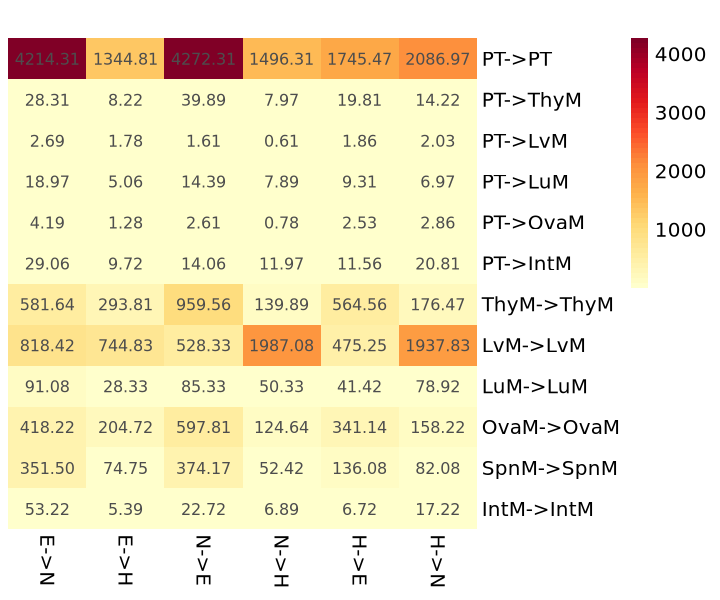

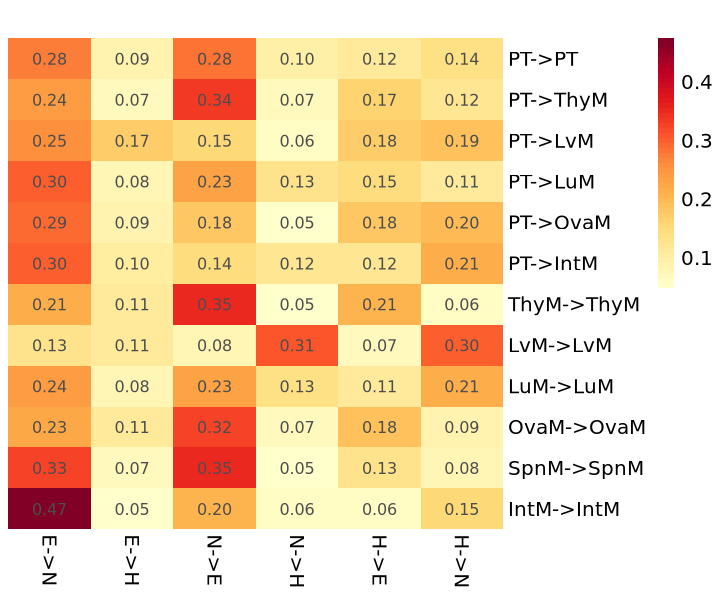

In [242]:
columnOrder <- c("E->N","E->E","E->H","N->E","N->H","N->N","H->E","H->H","H->N")
rowOrder <- c("PT->PT","PT->ThyM","PT->LvM","PT->LuM","PT->OvaM","PT->SpnM","PT->IntM",
              "ThyM->PT","ThyM->ThyM","ThyM->LvM","ThyM->LuM","ThyM->OvaM","ThyM->SpnM","ThyM->IntM",
              "LvM->PT","LvM->ThyM","LvM->LvM","LvM->LuM","LvM->OvaM","LvM->SpnM","LvM->IntM",
              "LuM->PT","LuM->ThyM","LuM->LvM","LuM->LuM","LuM->OvaM","LuM->SpnM","LuM->IntM",
              "OvaM->PT","OvaM->ThyM","OvaM->LvM","OvaM->LuM","OvaM->OvaM","OvaM->IntM",
              "SpnM->PT","SpnM->ThyM","SpnM->LvM","SpnM->LuM","SpnM->OvaM","SpnM->SpnM","SpnM->IntM",
              "IntM->PT","IntM->ThyM","IntM->LvM","IntM->LuM","IntM->OvaM","IntM->IntM")
rowOrder <- c("PT->PT","PT->ThyM","PT->LvM","PT->LuM","PT->OvaM","PT->SpnM","PT->IntM",
              "ThyM->ThyM","LvM->LvM","LuM->LuM","OvaM->OvaM","SpnM->SpnM","IntM->IntM")

dt <- dt_alltranstions
df_transitions <- dt %>%
  mutate(
    parent_state = case_when(
      parent_state %in% c("0","3","7","8") ~ "E",
      parent_state %in% c("1","2","5") ~ "N",
      parent_state %in% c("4","6") ~ "H",
      TRUE ~ parent_state
    ),
    child_state = case_when(
      child_state %in% c("0","3","7","8") ~ "E",
      child_state %in% c("1","2","5") ~ "N",
      child_state %in% c("4","6") ~ "H",
      TRUE ~ child_state
    )
  )
# df_transitions <- df_transitions %>% filter(parent_organ != child_organ & parent_state != child_state)
df_transitions <- df_transitions %>% filter(parent_state != child_state)
# 拼接 parent->child 和 state->state
df_transitions <- df_transitions %>%
  mutate(
    organ_transition = paste(parent_organ, child_organ, sep = "->"),
    state_transition = paste(parent_state, child_state, sep = "->")
  )

# 转成矩阵：行=organ_transition，列=state_transition，值=count
mat <- df_transitions %>%
  select(organ_transition, state_transition, count) %>%
  group_by(organ_transition, state_transition) %>% 
  summarise(count = sum(count), .groups = "drop") %>%
  pivot_wider(
    names_from = state_transition,
    values_from = count,
    values_fill = 0
  )

mat <- as.data.frame(mat)
rownames(mat) <- mat$organ_transition
mat <- mat[,-1]  # 删除 organ_transition 列

mat <- as.matrix(mat)
columnOrder <- columnOrder[columnOrder %in% colnames(mat)]
rowOrder <- rowOrder[rowOrder %in% row.names(mat)]
mat <- mat[,columnOrder]
mat <- mat[rowOrder,]
mat <- mat[rowSums(mat)>5,]

options(repr.plot.width =6, repr.plot.height = 5) 
colors <- rev(colorRampPalette(rev(brewer.pal(n = 9, name = "YlOrRd")))(50))
p <- pheatmap(mat,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  display_numbers = TRUE,
  # number_format = "%d",
  show_rownames = TRUE,
  show_colnames = TRUE,main="",
  fontsize = 12, 
  fontsize_row = 12,
  fontsize_col = 12,
  color = colors,
  # breaks = breaks,
  border_color = NA 
)  


row_sums <- rowSums(mat)
row_sums
mat <- mat/ row_sums

options(repr.plot.width =6, repr.plot.height = 5) 
colors <- rev(colorRampPalette(rev(brewer.pal(n = 9, name = "YlOrRd")))(50))
p <- pheatmap(mat,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  display_numbers = TRUE,
  # number_format = "%d",
  show_rownames = TRUE,
  show_colnames = TRUE,main="",
  fontsize = 12,
  fontsize_row = 12,
  fontsize_col = 12,
  color = colors,
  # breaks = breaks,
  border_color = NA 
)  

In [238]:
mat

,E->N,E->H,N->E,N->H,H->E,H->N
PT->PT,4214.305556,1344.805556,4272.305556,1496.3055556,1745.472222,2086.972222
PT->ThyM,28.305556,8.222222,39.888889,7.9722222,19.805556,14.222222
PT->LvM,2.694444,1.777778,1.611111,0.6111111,1.861111,2.027778
PT->LuM,18.972222,5.055556,14.388889,7.8888889,9.305556,6.972222
PT->OvaM,4.194444,1.277778,2.611111,0.7777778,2.527778,2.861111
PT->IntM,29.055556,9.722222,14.055556,11.9722222,11.555556,20.805556
ThyM->ThyM,581.638889,293.805556,959.555556,139.8888889,564.555556,176.472222
LvM->LvM,818.416667,744.833333,528.333333,1987.0833333,475.250000,1937.833333
LuM->LuM,91.083333,28.333333,85.333333,50.3333333,41.416667,78.916667
OvaM->OvaM,418.222222,204.722222,597.805556,124.6388889,341.138889,158.222222


pdf 
  2

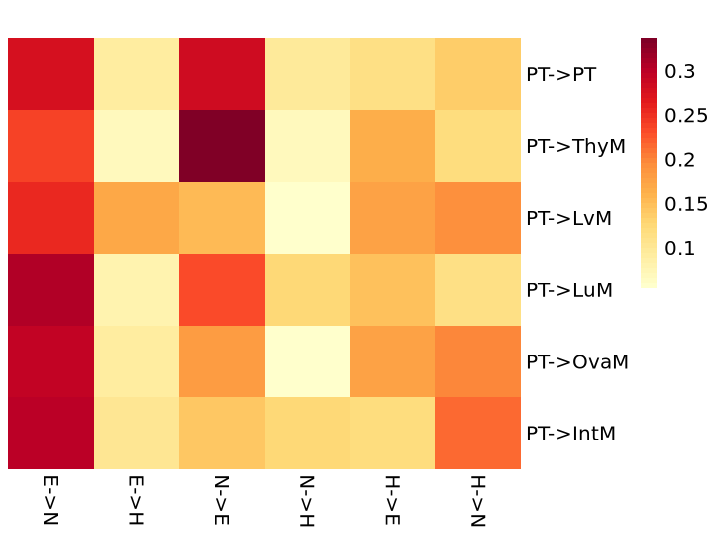

In [241]:
options(repr.plot.width =6, repr.plot.height = 4.5) 
p <- pheatmap(mat[1:6,],
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  display_numbers = FALSE,
  # number_format = "%d",
  show_rownames = TRUE,
  show_colnames = TRUE,main="",
  fontsize = 12, 
  fontsize_row = 12,
  fontsize_col = 12,
  color = colors,
  # breaks = breaks,
  border_color = NA
)  
pdf(file ="/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.5.CARTA/PT_met_all.pdf",width = 5.5,height =4,onefile = TRUE)
p
dev.off()

pdf 
  2

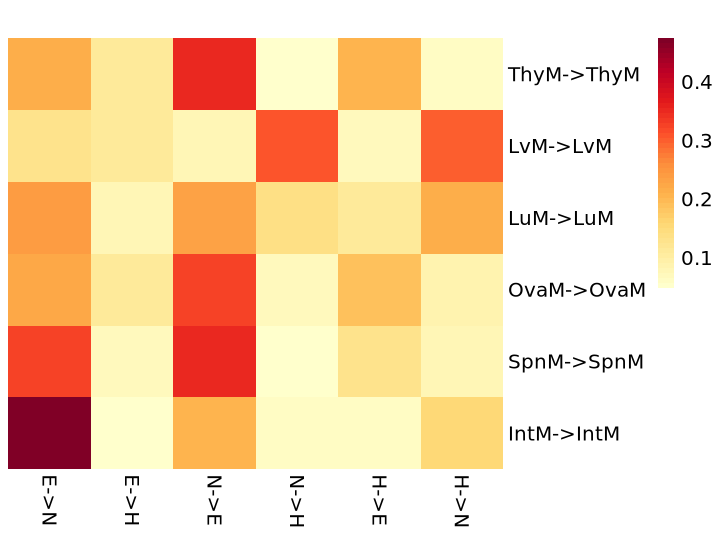

In [195]:
options(repr.plot.width =6, repr.plot.height = 4.5) 
p <- pheatmap(mat[5:10,],
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  display_numbers = FALSE,
  # number_format = "%d",
  show_rownames = TRUE,
  show_colnames = TRUE,main="",
  fontsize = 12, 
  fontsize_row = 12, 
  fontsize_col = 12, 
  color = colors,
  # breaks = breaks,
  border_color = NA 
)  
pdf(file ="/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.5.CARTA/Metastatic-tropic.pdf",width = 6,height =4.5,onefile = TRUE)
p
dev.off()
